In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.fit import *

from pmt.fit.core import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [2]:
file_name = "WA0089_850V_20MHz_Cold_led1"
# file_name = "WA0089_850V_20MHz_Cold_led2"
# file_name = "WA0089_850V_20MHz_Cold_led3"
# file_name = "WA0089_850V_20MHz_Cold_led4"
# file_name = "WA0089_850V_20MHz_Cold_led5"
# file_name = "WA0089_850V_20MHz_Cold_led6"
# file_name = "WA0089_850V_20MHz_Cold_led7"
# file_name = "WA0089_850V_20MHz_Cold_led8"
# file_name = "WA0089_850V_20MHz_Cold_led9"
data_dir = Path("data/WA0089/LED_sweep/260615")

# Set to a number for quick iteration, or None to use all matching files.
max_files = 1

files = find_pmt_files(data_dir, file_name, max_files=max_files)

for file in files:
    print(file)
print(f"Number of files loaded: {len(files)}")


data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-1.h5
Number of files loaded: 1


### if and where to save plots

In [3]:
save_plots = True
save_dir = 'plots_fit_results'
file_nickname = file_name

# Configuration

In [4]:
cfg = load_config("config_default.yml", file_name)
print(cfg)

[general]
baseline_window_width_ns = 20
integration_window_ns = (30, 80)
peak_search_window_ns = (30, 80)
global_peak_voltage_max_mV = None
out_of_window_peak_voltage_max_mV = -1.0
allowed_peak_window_ns = (30, 40)

[fit_general]
fit_range = (-15.0, 80.0)
fit_nbins = 250



In [5]:
chunk_size = 512 #4096

baseline_window_width_ns          = cfg.general.baseline_window_width_ns
integration_window_ns             = cfg.general.integration_window_ns

# refactor: make this one variable
peak_search_window_ns             = cfg.general.peak_search_window_ns  
allowed_peak_window_ns            = cfg.general.allowed_peak_window_ns
# peak_time_window_mV = 
out_of_window_peak_voltage_max_mV = cfg.general.out_of_window_peak_voltage_max_mV
# peak_finding_threshold_mV = 

selection_peak_threshold_max_mV        = cfg.general.global_peak_voltage_max_mV
# baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + config["baseline_window_width_ns"]))



In [6]:
max_sample_events = 2

sample = read_waveform_sample(files, max_events=max_sample_events)
time_ns = sample["time_ns"]
adc_step_mV = sample["adc_step_mV"]

print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV\n")
print(sample.keys())

baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + baseline_window_width_ns))

Time range: -0.029 to 99.971 ns
Sampling step: 0.06250 ns
ADC step: 0.000214 mV

dict_keys(['time_ns', 'voltage_mV', 'metadata', 'sample_segments', 'adc_step_mV', 'units_time', 'units_voltage'])


# Load Sample and compute charge


In [7]:
prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    baseline_subtraction=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None,
    high_limit_mV=None,
    margin_mV=0.0,
    max_saturated_samples=0
)

time_ns = prerocessed_data["time_ns"]
voltage_mV = prerocessed_data["voltage_mV"]
# baseline_mV = prerocessed_data["baseline_mV"]

print(f"Preprocessed sample: {prerocessed_data["voltage_mV"].shape}")
print(f"Efficiency of saturation cut: {prerocessed_data['saturation_summary']['efficiency']*100:.3f} %")

remove = ['is_saturated', 'n_saturated_samples']
preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in remove}

prerocessed_data.keys()



Preprocessed sample: (31677, 1601)
Efficiency of saturation cut: 99.984 %


dict_keys(['time_ns', 'voltage_mV', 'event_file', 'event_segment', 'event_info', 'saturation_summary'])

# Selection

In [8]:
df =  build_waveform_feature_dataframe( time_ns, voltage_mV, extra=preprocessed_event_info)
df

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a prominence of 0
  widths, width_heights, left_ips, right_ips = peak_widths(
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a width of 0
  widths, width_heights, left_ips, right_ips = peak_widths(


,peak_time_ns,peak_idx,peak_amplitude_mV,fwhm_ns,peak_width_ns,rise_time_10_90_ns,fall_time_90_10_ns,cfd10_rise_ns,cfd20_rise_ns,cfd30_rise_ns,...,charge_cfd50_window_mV_ns,n_peaks,second_peak_time_ns,second_peak_amplitude_mV,peak_separation_ns,event_id,baseline_mean_mV,baseline_rms_mV,baseline_slope_mV_per_ns,snr
0,48.845558,782,0.154285,70.5000,1.560707,42.199937,0.532167,6.403388,8.529605,28.253228,...,0.342312,29,60.220558,0.127556,11.3750,0,-0.417220,0.022482,-0.001616,6.862754
1,92.033058,1473,0.188668,42.9375,1.841262,91.338668,NaN,-0.029442,0.408747,48.570819,...,3.794535,63,92.158058,0.188455,0.1250,1,-0.354397,0.022482,0.003139,8.391824
2,57.345558,918,0.120700,20.3125,1.777084,48.114020,0.595384,9.020464,9.512987,12.433460,...,-2.513309,24,48.845558,0.086273,-8.5000,2,-0.399058,0.027165,-0.002721,4.443178
3,28.658058,459,0.157816,51.5000,2.813405,25.345305,1.105513,2.930133,6.146375,10.582930,...,-4.199344,16,19.470558,0.133653,-9.1875,3,-0.439135,0.064233,-0.001729,2.456924
4,48.845558,782,0.105275,36.3750,1.553911,39.622366,0.457094,9.044411,9.238400,9.487635,...,-1.933412,31,60.283058,0.086672,11.4375,4,-0.459601,0.036709,-0.005404,2.867852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31672,49.158058,787,0.217527,37.8125,1.651498,39.613671,0.731168,9.269205,22.715601,23.150449,...,2.654093,22,60.283058,0.166635,11.1250,31672,-0.385412,0.020334,-0.002280,10.697623
31673,33.033058,529,0.173565,48.3750,8.305761,16.145550,2.543906,16.337645,16.789123,17.181924,...,2.384803,40,32.908058,0.173137,-0.1250,31673,-0.408205,0.034971,-0.005231,4.963080
31674,49.033058,785,0.175635,49.0000,1.583266,36.239575,0.684359,12.554338,12.979967,16.253075,...,4.044895,31,65.908058,0.161308,16.8750,31674,-0.358022,0.027580,-0.002939,6.368097
31675,49.220558,788,0.175177,70.8125,1.600864,48.965412,0.734325,-0.029442,0.214581,2.997021,...,3.652155,62,40.970558,0.150800,-8.2500,31675,-0.389272,0.029175,0.003554,6.004360


In [9]:
# reject events with main peak inside the baseline window -> the baseline computation fails when the peak in inside
# optional: require the peak to be larger than a specific  value (e.g. 0.5mV) so that we don't thouw away pedestal events
sanity_mask_reject = ( df.peak_time_ns.between( baseline_window_ns[0], baseline_window_ns[1] ) & (df.peak_amplitude_mV >= 0.5) )
sanity_mask_keep = ~sanity_mask_reject

In [10]:
df_sel = df[sanity_mask_keep].copy()
waveforms_sel = voltage_mV[df_sel["event_id"].values]

### Charge Computation

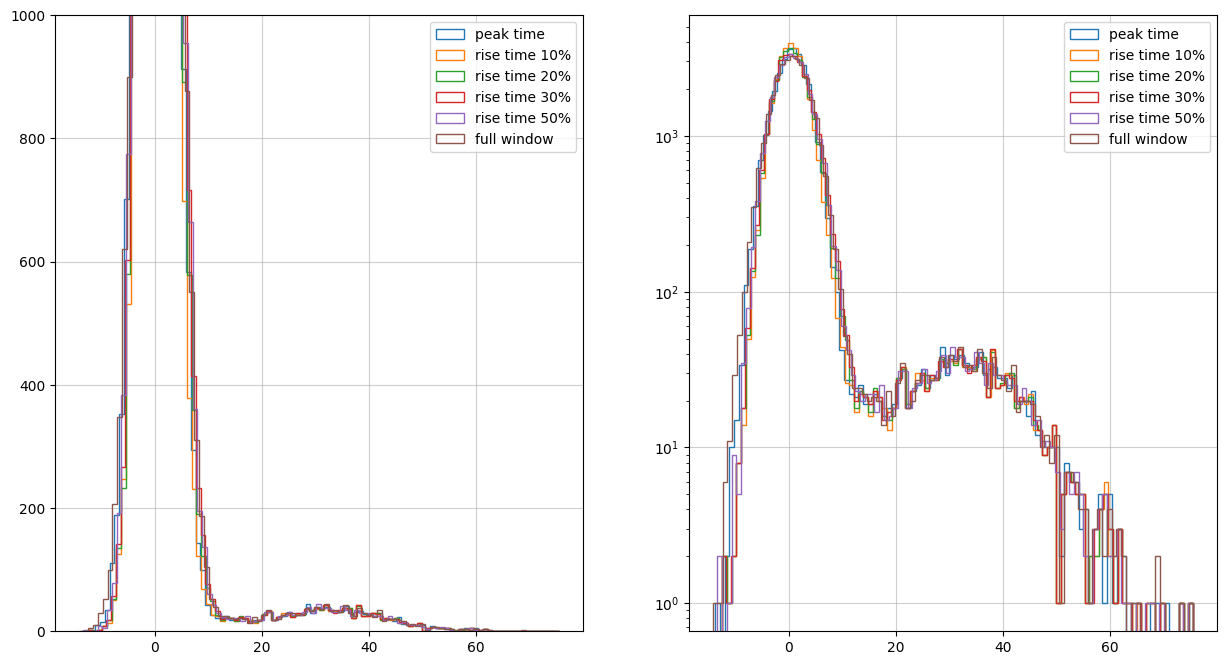

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))


rg = None #(-20, 10)
den=False

axes[0].hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes[0].hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes[0].hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes[0].hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes[0].hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes[0].hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes[0].set_ylim(0, 1000)
axes[0].legend();

axes[1].hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes[1].hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes[1].hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes[1].hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes[1].hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes[1].hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes[1].set_yscale('log');
axes[1].legend();




# Fits

In [12]:
charge_mV_ns = df_sel.charge_cfd20_window_mV_ns.values # chose one charge distribution
fit_range = (np.min(charge_mV_ns), np.max(charge_mV_ns))
fit_range


(np.float64(-12.416380770504476), np.float64(75.44618597254158))

In [13]:
with open('config_default.yml', 'r') as file:
    # Load and parse the YAML content safely
    fit_general = yaml.safe_load(file)[file_name]['fit_general']

fit_range = (fit_general['fit_range'][0], fit_general['fit_range'][1])
nbins = fit_general['fit_nbins']

fit_general

{'fit_range': [-15.0, 80.0], 'fit_nbins': 250}

## Simple Poisson Model

In [14]:
from pmt.fit.poisson import fit_poisson_spe, poisson_npe_fractions

,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,31673.00,15836.5000,63346.0,False,31187.759983,176.664260
1,mu_pe,0.03,0.0010,5.0,False,0.036476,0.001229
2,q0_mV_ns,0.30,-6.0000,10.0,False,0.602207,0.017144
3,sigma0_mV_ns,2.50,0.0001,50.0,False,2.915271,0.012374
4,q1_mV_ns,29.00,1.0000,40.0,False,28.129897,0.563735
5,sigma1_mV_ns,12.00,0.2000,20.0,False,12.265366,0.499669


Photoelectron fractions
----------------------------------------
 0 PE :  96.418%   (   30070.7 events)
 1 PE :   3.517%   (    1096.9 events)
 2 PE :   0.064%   (      20.0 events)
 3 PE :   0.001%   (       0.2 events)
----------------------------------------
sum = 100.000%
{0: np.float64(0.9641814308346668), 1: np.float64(0.03516928500469565), 2: np.float64(0.0006414138294857932), 3: np.float64(7.798693293512615e-06)}


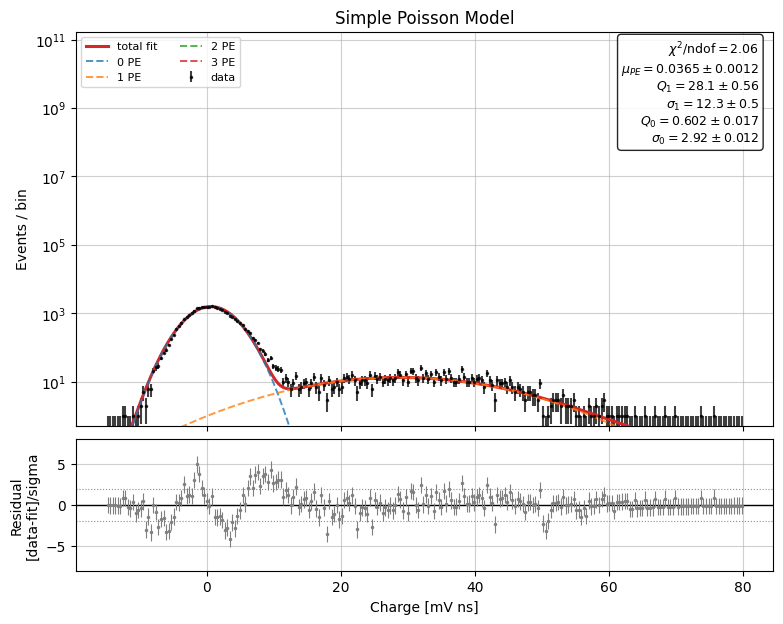

In [21]:
maxPE = 3

p0_poisson = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    # Set isFixed=True to hold a parameter at the initial value during the fit.
    "n_total":      [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False],
    "q1_mV_ns":     [29.0, 1.0, 40.0,  False],
    "sigma1_mV_ns": [12.0, 0.2, 20.0,  False],
    "mu_pe":        [0.03, 0.001, 5.0, False],
}

fit_poisson = fit_poisson_spe(
    charge_mV_ns,
    p0=p0_poisson,
    max_pe=maxPE,
    fit_range=fit_range
)

table_poisson = fit_result_table(fit_poisson)
display( table_poisson )

fig, ax, ax_resid = plot_fit_result( 
    fit_poisson,
    title="Simple Poisson Model", 
    logscale=True,
    # ylims= (0, 600),
    component_visibility_fraction=0, #1e-3,
    )

poisson_evt_fractions = poisson_npe_fractions( fit_poisson, maxPE)
print_npe_fractions( poisson_evt_fractions, n_total=fit_poisson["parameters"]["n_total"] )

print(poisson_evt_fractions)
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Poisson",  Nevents=None);

# Bellamy's model

In [17]:
from pmt.fit.bellamy import fit_bellamy_spe



,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,31673.00,15836.5000,63346.0,False,31482.635713,183.343857
1,mu_pe,0.03,0.0010,5.0,False,0.032239,0.001256
2,q0_mV_ns,0.27,-6.0000,10.0,False,-1.061844,118042.691288
3,sigma0_mV_ns,2.30,0.0001,50.0,False,2.501125,2.239384
4,q1_mV_ns,30.00,5.0000,50.0,False,30.812141,0.434027
5,sigma1_mV_ns,12.00,0.2000,30.0,False,9.899839,0.395528
6,w,0.20,0.0000,1.0,False,0.999973,68390.316247
7,alpha,0.30,0.0000,10.0,False,0.579369,0.013408


Photoelectron fractions
----------------------------------------
 0 PE :  96.828%   (   30483.9 events)
 1 PE :   3.122%   (     982.8 events)
 2 PE :   0.050%   (      15.8 events)
 3 PE :   0.001%   (       0.2 events)
----------------------------------------
sum = 100.000%


[PosixPath('plots_fit_results/WA0089_850V_20MHz_Cold_led1_fit_Bellamy.pdf')]

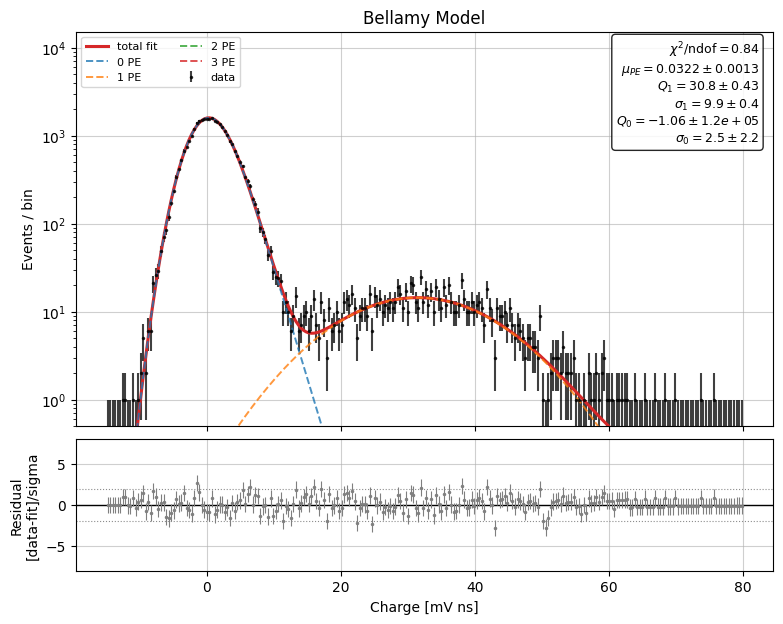

In [ ]:
maxPE = 3

p0_bellamy = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    "n_total":      [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns":     [0.27, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.3, 1e-4, 50.0,   False],
    "q1_mV_ns":     [30.0, 5.0, 50.0,   False],
    "sigma1_mV_ns": [12.0, 0.2, 30.0,   False],
    "mu_pe":        [0.03, 0.001, 5.0,  False],
    "w":            [0.2, 0., 1.,       False],
    "alpha":        [0.3, 0., 10.,      False], # positive
}

fit_bellamy = fit_bellamy_spe(
    charge_mV_ns,
    p0=p0_bellamy,
    max_pe=maxPE,
    fit_range=fit_range
)

table_bellamy = fit_result_table(fit_bellamy)
display( table_bellamy )

fig, ax, ax_resid = plot_fit_result( 
    fit_bellamy,
    title="Bellamy Model", 
    logscale=True,
    # ylims= (0, 600),
    component_visibility_fraction=0, #1e-3,
    )

bellamy_evt_fractions = poisson_npe_fractions( fit_bellamy, maxPE)
print_npe_fractions( bellamy_evt_fractions, n_total=fit_bellamy["parameters"]["n_total"] )

save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Bellamy",  Nevents=None);

# Fit Comparison

In [16]:
for fit in [fit_poisson, fit_bellamy]:

    chi2_ndof = (
        fit["chi2"] /
        fit["ndof"]
    )

    print(
        fit["model"].name,
        f"chi2/ndof = {chi2_ndof:.3f}"
    )

# because chi2 is almost always smaller when adding parameters, it's better to look at 
def fit_aic(fit):
    # Akaike Information Criterion
    # least-squares fits with Gaussian uncertainties
    # smaller the better
    n_params = len( fit["fitted_parameter_names"] )
    return ( fit["chi2"] + 2 * n_params) # for 

print( "Poisson AIC:", 
      fit_aic( fit_poisson) )
print( "Bellamy AIC:", fit_aic( fit_bellamy) )
print( f"Delta AIC (i.e. is adding more parameters worth it?) {fit_aic( fit_poisson) - fit_aic( fit_bellamy):.2f}")
##
# 0–2 models essentially equivalent
# 4–7 some evidence against larger AIC
# >10 strong evidence against larger AIC


NameError: name 'fit_bellamy' is not defined

NameError: name 'fit_bellamy' is not defined

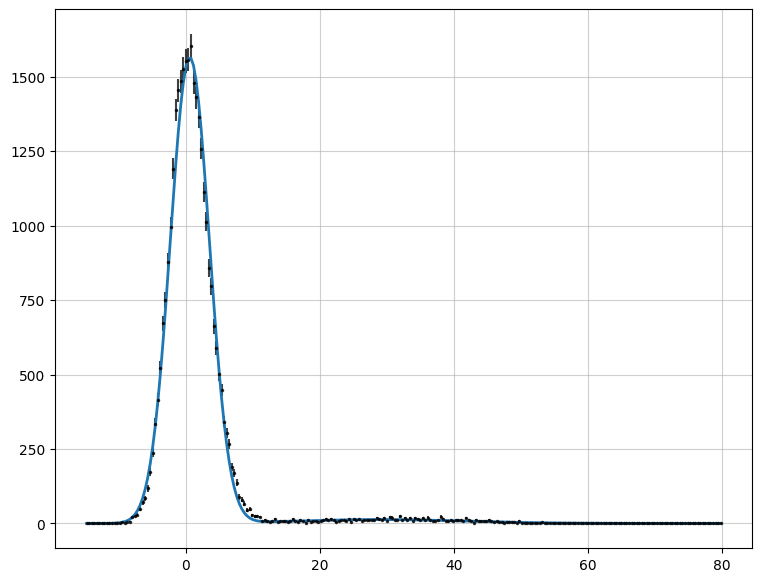

In [17]:

fig, ax = plt.subplots( 1, 1, figsize=(9, 7), gridspec_kw={"height_ratios": [3], "hspace": 0.05},)

ax.errorbar(
    fit_poisson["centers"],
    fit_poisson["counts"],
    yerr=np.sqrt( np.maximum( fit_poisson["counts"], 1 ) ),
    fmt=".",
    ms=3,
    color="black",
    alpha=0.75,
    label="data",
)

ax.plot(
    fit_poisson["centers"],
    fit_poisson["model_counts"],
    lw=2,
    label="Poisson",
)

ax.plot(
    fit_bellamy["centers"],
    fit_bellamy["model_counts"],
    lw=2,
    label="Bellamy",
)

ax.set_yscale("log")
ax.set_title("Fit model comparison")

ax.set_xlabel("Charge [mV ns]")
ax.set_ylabel("Events / bin")

ax.legend();


save_plot(fig, save_plots, save_dir, file_nickname, f"fit_pdf_comparison",  Nevents=None);

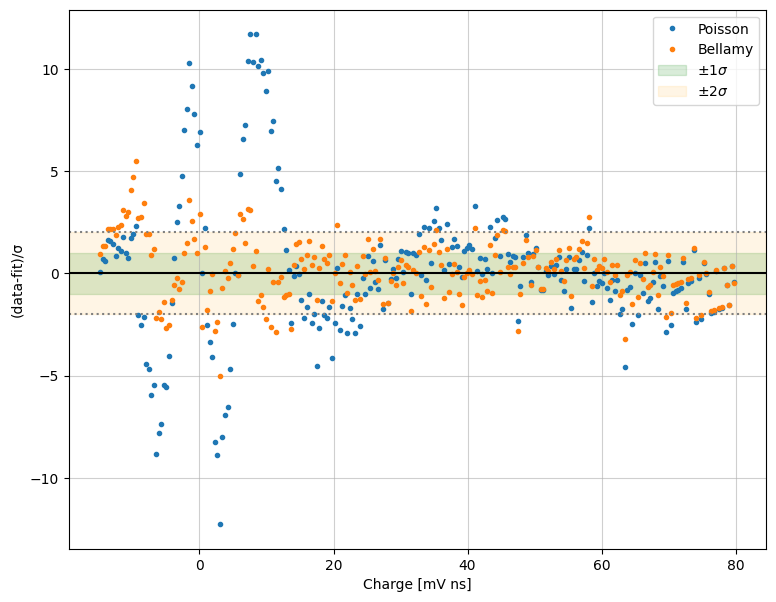

In [ ]:

fig, ax = plt.subplots( 1, 1, figsize=(9, 7), gridspec_kw={"height_ratios": [3], "hspace": 0.05})

counts = fit_poisson["counts"]

sigma = np.sqrt( np.maximum( counts, 1, ))

res_poisson = ( counts - fit_poisson["model_counts"] ) / sigma
res_bellamy = ( counts - fit_bellamy["model_counts"] ) / sigma

ax.plot( fit_poisson["centers"], res_poisson, ".", label="Poisson" )
ax.plot( fit_bellamy["centers"], res_bellamy, ".", label="Bellamy" )

ax.axhline( 0, color="black" )
ax.axhline( 2, color="gray", ls=":" )
ax.axhline( -2, color="gray", ls=":" )

ax.axhspan( -1, 1, alpha=0.15,  color="green", label=r"$\pm1\sigma$" )
ax.axhspan( -2, 2, alpha=0.10 , color="orange", label=r"$\pm2\sigma$")

ax.legend()

ax.set_xlabel("Charge [mV ns]")
ax.set_ylabel("(data-fit)/σ")

save_plot(fig, save_plots, save_dir, file_nickname, f"fit_residual_comparison",  Nevents=None);



In [ ]:
poisson_table = fit_result_table(
    fit_poisson
)

bellamy_table = fit_result_table(
    fit_bellamy
)

display(poisson_table)

display(bellamy_table)

,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,316737.00,158368.5000,633474.0,False,313699.697286,560.150355
1,mu_pe,0.03,0.0010,5.0,False,0.047029,0.000439
2,q0_mV_ns,0.30,-6.0000,10.0,False,0.590554,0.005476
3,sigma0_mV_ns,2.50,0.0001,50.0,False,2.940587,0.004062
4,q1_mV_ns,29.00,1.0000,40.0,False,28.177847,0.172725
5,sigma1_mV_ns,12.00,0.2000,20.0,False,13.242018,0.140445


,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,316737.00,158368.5000,633474.0,False,316219.498770,562.405923
1,mu_pe,0.03,0.0010,5.0,False,0.041911,0.000410
2,q0_mV_ns,0.27,-6.0000,10.0,False,-1.047350,6335.807935
3,sigma0_mV_ns,2.30,0.0001,50.0,False,2.528549,5.560583
4,q1_mV_ns,30.00,5.0000,50.0,False,30.871114,0.148889
5,sigma1_mV_ns,12.00,0.2000,30.0,False,11.317750,0.130672
6,w,0.20,0.0000,1.0,False,0.998700,3706.291758
7,alpha,0.30,0.0000,10.0,False,0.584974,0.006810
